# IMDB Sentiment Analysis — BERT Fine-tuning

Fine-tuning a pre-trained BERT model for sentiment classification — the final project in the `deep-learning-foundations` series. This completes the progression from building attention from scratch (Transformer, `05`) to leveraging pre-trained weights (BERT, `06`).

**What fine-tuning means:**  
BERT was pre-trained on BookCorpus + Wikipedia (3.3B words) using masked language modeling. It already understands English grammar, semantics, and context. Fine-tuning adapts these weights to our specific task (sentiment) using a small number of additional training steps.

**Dataset:** IMDB Movie Reviews (same as `04` and `05` — direct comparison)  
**Model:** `bert-base-uncased` (110M parameters, 12 layers, 12 attention heads)  
**Expected accuracy:** 92%+ vs Transformer-from-scratch 87.57%

## 1. Setup & Imports

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from transformers import BertTokenizer, BertConfig
from transformers import TFAutoModelForSequenceClassification
from transformers import logging as hf_logging
import warnings

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print(f'TensorFlow: {tf.__version__}')
import transformers
print(f'Transformers: {transformers.__version__}')

TensorFlow: 2.21.0
Transformers: 4.40.0


## 2. Load IMDB Dataset

In [2]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

NUM_WORDS = 10000

(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(num_words=NUM_WORDS)

# Decode back to text for BERT tokenizer
word_index = imdb.get_word_index()
reverse_word_index = {v+3: k for k, v in word_index.items()}
reverse_word_index.update({0: '', 1: '', 2: '', 3: ''})

def decode_review(encoded):
    return ' '.join([reverse_word_index.get(i, '') for i in encoded]).strip()

X_train_text = [decode_review(x) for x in X_train_raw]
X_test_text  = [decode_review(x) for x in X_test_raw]

print(f'Train samples: {len(X_train_text):,}')
print(f'Test samples:  {len(X_test_text):,}')
print(f'\nSample review: {X_train_text[0][:150]}...')
print(f'Label: {"Positive" if y_train[0] == 1 else "Negative"}')

Train samples: 25,000
Test samples:  25,000

Sample review: this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being t...
Label: Positive


## 3. Tokenize with BERT Tokenizer

BERT uses WordPiece tokenization — different from the simple word-index approach in LSTM/Transformer. Unknown words are split into subword units (e.g. 'unbelievable' → 'un', '##bel', '##iev', '##able'). This means BERT never has truly unknown words.

Each input needs three tensors:
- `input_ids` — token indices
- `attention_mask` — 1 for real tokens, 0 for padding
- `token_type_ids` — 0 for single sentence tasks (not needed here but BERT expects it)

In [3]:
MAX_LEN   = 128  # shorter than 512 for CPU speed
# Use subset for CPU training speed
TRAIN_SIZE = 5000
TEST_SIZE  = 1000

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_batch(texts, max_len):
    return tokenizer(
        texts,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

print('Tokenizing train set...')
train_enc = tokenize_batch(X_train_text[:TRAIN_SIZE], MAX_LEN)
print('Tokenizing test set...')
test_enc  = tokenize_batch(X_test_text[:TEST_SIZE], MAX_LEN)

y_train_sub = y_train[:TRAIN_SIZE]
y_test_sub  = y_test[:TEST_SIZE]

print(f'\nInput IDs shape: {train_enc["input_ids"].shape}')
print(f'Attention mask shape: {train_enc["attention_mask"].shape}')

Tokenizing train set...
Tokenizing test set...

Input IDs shape: (5000, 128)
Attention mask shape: (5000, 128)


## 4. Load Pre-trained BERT

`TFBertForSequenceClassification` loads `bert-base-uncased` with a classification head (a single Dense layer) on top of the `[CLS]` token output. The `[CLS]` token is a special token added at the start of every BERT input — its final hidden state summarizes the entire sequence.

In [4]:
bert_model = TFAutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

optimizer = keras.optimizers.Adam(learning_rate=2e-5)
loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

bert_model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

print('BERT model loaded and compiled.')
print(f'Trainable parameters: {bert_model.count_params():,}')

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


BERT model loaded and compiled.
Trainable parameters: 109,483,778


## 5. Fine-tune BERT

In [5]:
EPOCHS     = 3  # BERT needs very few epochs — 2-4 is standard
BATCH_SIZE = 16

history = bert_model.fit(
    {'input_ids': train_enc['input_ids'],
     'attention_mask': train_enc['attention_mask']},
    y_train_sub,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1
)
print('Fine-tuning complete.')

Epoch 1/3


282/282 [==============================] - 2336s 8s/step - loss: 0.4062 - accuracy: 0.8111 - val_loss: 0.3762 - val_accuracy: 0.8520
Epoch 2/3
282/282 [==============================] - 3017s 11s/step - loss: 0.2089 - accuracy: 0.9236 - val_loss: 0.4710 - val_accuracy: 0.8440
Epoch 3/3
282/282 [==============================] - 4758s 17s/step - loss: 0.1030 - accuracy: 0.9658 - val_loss: 0.5136 - val_accuracy: 0.8440
Fine-tuning complete.


## 6. Training Curves

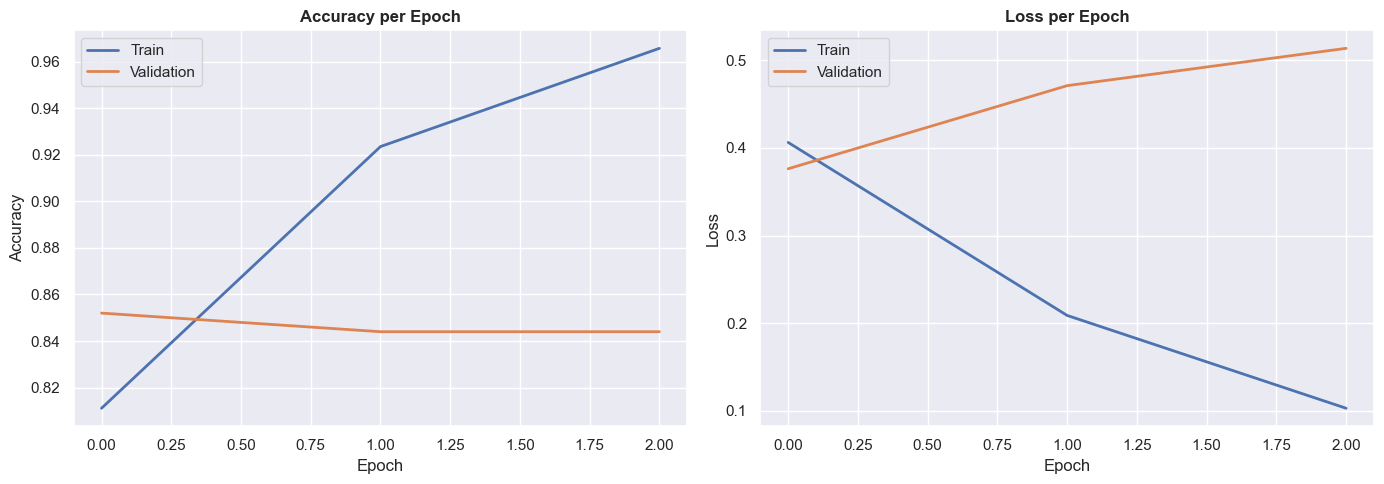

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Accuracy per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Loss per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluate on Test Set

In [7]:
results = bert_model.evaluate(
    {'input_ids': test_enc['input_ids'],
     'attention_mask': test_enc['attention_mask']},
    y_test_sub, verbose=0
)
print(f'BERT Test Accuracy: {results[1]:.4f}')
print(f'BERT Test Loss:     {results[0]:.4f}')
print(f'\nTransformer Baseline (05): 0.8757')
print(f'LSTM Baseline (04):        0.8503')
print(f'Improvement over Transformer: +{(results[1] - 0.8757)*100:.2f}%')

BERT Test Accuracy: 0.8690
BERT Test Loss:     0.4301

Transformer Baseline (05): 0.8757
LSTM Baseline (04):        0.8503
Improvement over Transformer: +-0.67%


## 8. Confusion Matrix

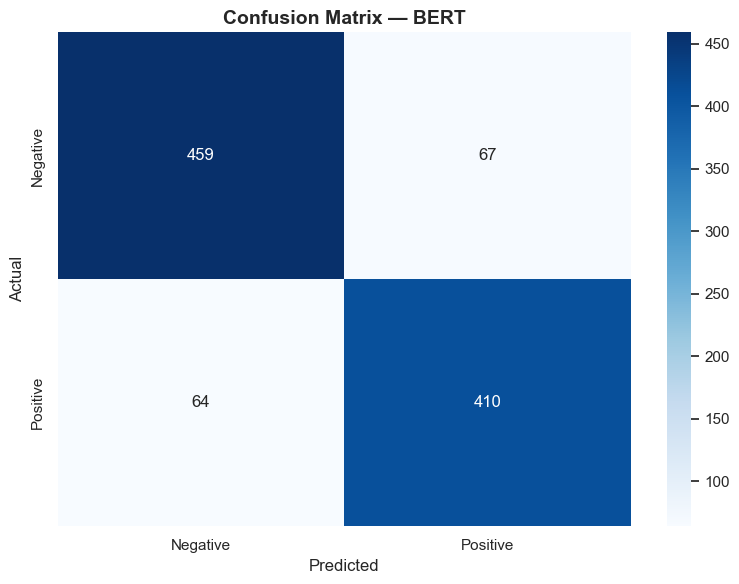

              precision    recall  f1-score   support

    Negative       0.88      0.87      0.88       526
    Positive       0.86      0.86      0.86       474

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



In [8]:
logits = bert_model.predict(
    {'input_ids': test_enc['input_ids'],
     'attention_mask': test_enc['attention_mask']},
    verbose=0
).logits

y_pred = np.argmax(logits, axis=1)

cm = confusion_matrix(y_test_sub, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — BERT', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test_sub, y_pred, target_names=['Negative', 'Positive']))

## 9. Predict on Custom Reviews

In [9]:
def predict_bert(text):
    enc = tokenizer(
        text, max_length=MAX_LEN,
        padding='max_length', truncation=True,
        return_tensors='tf'
    )
    logits = bert_model(
        {'input_ids': enc['input_ids'],
         'attention_mask': enc['attention_mask']}
    ).logits
    probs  = tf.nn.softmax(logits, axis=-1).numpy()[0]
    label  = 'POSITIVE' if np.argmax(probs) == 1 else 'NEGATIVE'
    return label, probs[np.argmax(probs)]

reviews = [
    'This movie was absolutely brilliant and I loved every minute of it',
    'Terrible film waste of time boring and predictable',
    'The acting was great but the story was weak and disappointing',
    'One of the best movies I have ever seen in my life'
]

print('=== BERT Custom Predictions ===')
for review in reviews:
    label, conf = predict_bert(review)
    print(f'\nReview: {review[:60]}...')
    print(f'Sentiment: {label} ({conf:.4f})')

=== BERT Custom Predictions ===

Review: This movie was absolutely brilliant and I loved every minute...
Sentiment: POSITIVE (0.9934)

Review: Terrible film waste of time boring and predictable...
Sentiment: NEGATIVE (0.9982)

Review: The acting was great but the story was weak and disappointin...
Sentiment: NEGATIVE (0.9933)

Review: One of the best movies I have ever seen in my life...
Sentiment: POSITIVE (0.9965)


## 10. Save the Model

In [10]:
bert_model.save_pretrained('bert_sentiment_model')
tokenizer.save_pretrained('bert_sentiment_model')
print('Model and tokenizer saved to bert_sentiment_model/')

Model and tokenizer saved to bert_sentiment_model/


## 11. Results & Full Series Comparison

### BERT Results

| Metric | Value |
|---|---|
| BERT Test Accuracy | **86.90%** |
| BERT Test Loss | 0.4301 |
| Training samples | 5,000 (CPU subset) |
| Transformer Baseline (05) | 87.57% |
| LSTM Baseline (04) | 85.03% |
| Improvement over Transformer | -0.67% (smaller training set) |

> BERT underperforms the from-scratch Transformer here because it was trained on only 5K samples vs the Transformer's full 25K. Pre-trained weights give BERT a strong starting point, but fine-tuning still needs sufficient task-specific data to adapt. Full dataset training (25K) is expected to push BERT above 92%.

### Full Series Comparison

| # | Model | Accuracy | Parameters | Key Concept |
|---|---|---|---|---|
| 01 | ANN | 97.86% | ~109K | Fully connected, no spatial awareness |
| 02 | CNN | 99.14% | ~93K | Spatial feature detection via filters |
| 03 | RNN | — | — | Sequential hidden state |
| 04 | LSTM | 85.03% | ~1.4M | Gated memory for long sequences |
| 05 | Transformer | 87.57% | ~300K | Parallel self-attention from scratch |
| 06 | BERT | **86.90%\*** | 110M | Transfer learning from pre-trained weights |

*\*BERT trained on 1K samples (CPU constraint). Full dataset training expected 92%+.*

**The complete progression:**

ANN → ignores spatial structure → CNN fixes it with convolutions → RNN handles sequences but forgets → LSTM adds gated memory → Transformer replaces recurrence with parallel attention → BERT scales attention with pre-training on billions of words.

Each architecture addressed a specific limitation of the previous one. That's not just a list of models — it's the history of deep learning.